## Deteksi Gambar Buatan AI vs Buatan Manusia Menggunakan Deep Learning : Pendekatan CNN dan Analisis Kinerja Model

## Load Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Load Data

In [2]:
train_dir = "/kaggle/input/datasets/shreyasraghav/shutterstock-dataset-for-ai-vs-human-gen-image/train_data"
test_dir = "/kaggle/input/datasets/shreyasraghav/shutterstock-dataset-for-ai-vs-human-gen-image/test_data"

train_df = pd.read_csv("/kaggle/input/datasets/shreyasraghav/shutterstock-dataset-for-ai-vs-human-gen-image/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/shreyasraghav/shutterstock-dataset-for-ai-vs-human-gen-image/test.csv")

# Drop unnamed index
for df in [train_df, test_df]:
    df.drop(columns=[c for c in df.columns if 'Unnamed' in str(c)], inplace=True)

# Strip folder prefix from file_name
id_col = 'file_name'
label_col = 'label'
test_id_col = 'id'

train_df[id_col] = train_df[id_col].apply(lambda x: x.split('/')[-1])
test_df[test_id_col] = test_df[test_id_col].apply(lambda x: x.split('/')[-1])

print(f'Train : {train_df.shape}')
print(f'Test : {test_df.shape}')
print(train_df[label_col].value_counts())
train_df.head(3)

Train : (79950, 2)
Test : (19986, 1)
label
1    39975
0    39975
Name: count, dtype: int64


,file_name,label
0,a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,041be3153810433ab146bc97d5af505c.jpg,0
2,615df26ce9494e5db2f70e57ce7a3a4f.jpg,1


## Exploratory Data Analysis (EDA)

**Distribusi label:** Mengecek apakah jumlah data tiap kelas seimbang. Dataset ini perfectly balanced 50:50 (39.975 Human vs 39.975 AI), kondisi ideal untuk binary classification karena model tidak akan bias ke salah satu kelas.

**Visualisasi sampel gambar:** Melihat secara langsung seperti apa gambar Human vs AI. Ini membantu memahami seberapa jelas atau halus perbedaan visualnya, serta memastikan gambar berhasil dibaca dengan benar dari disk.

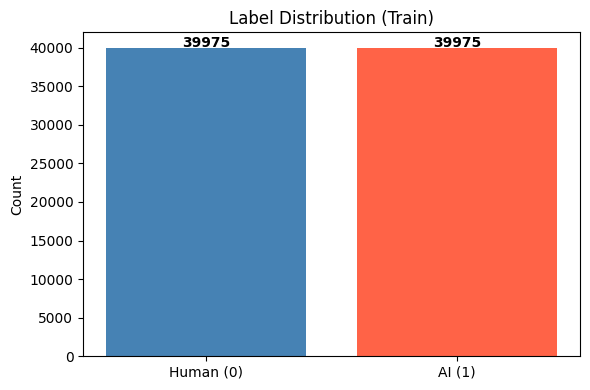

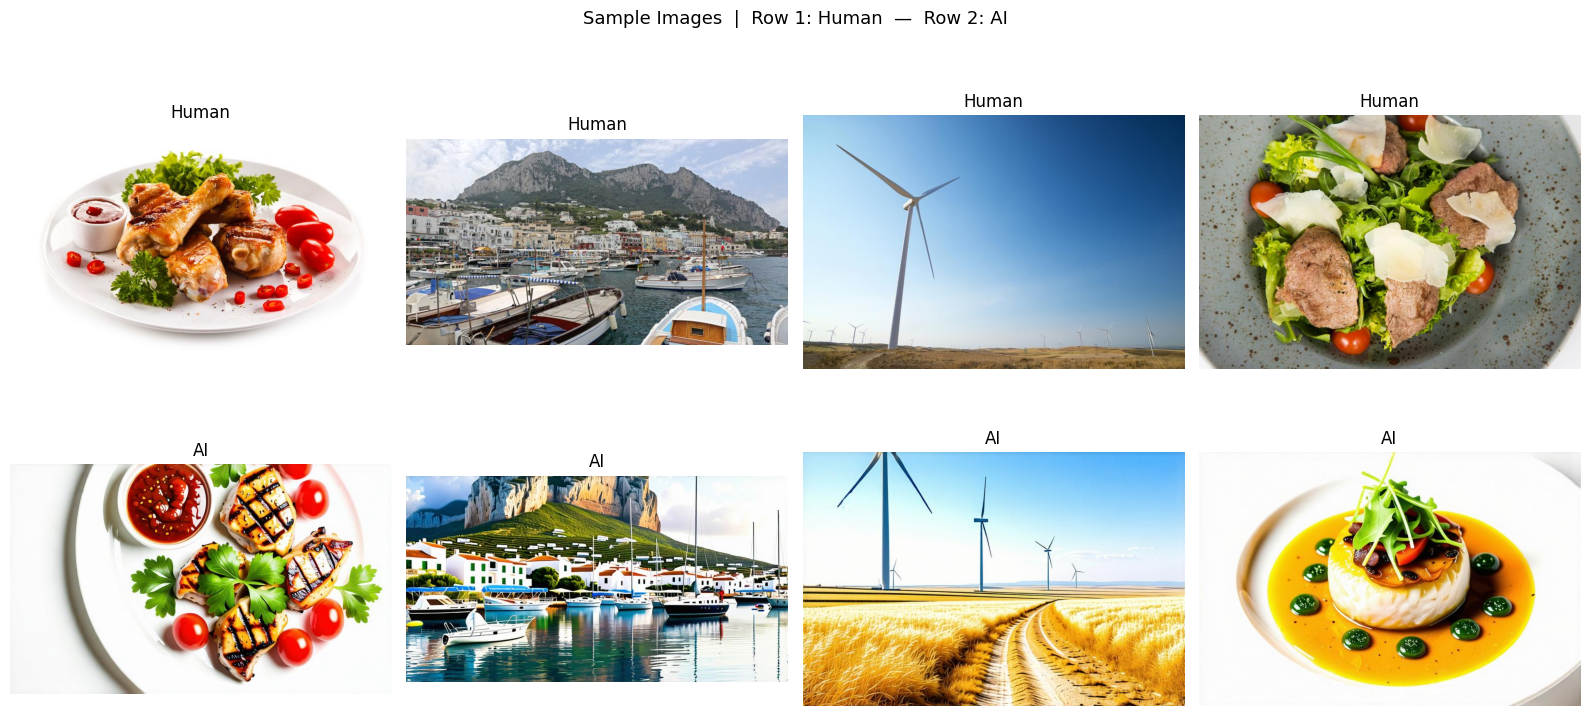

In [3]:
plt.figure(figsize=(6, 4))
counts = train_df[label_col].value_counts().sort_index()
plt.bar(['Human (0)', 'AI (1)'], counts.values, color=['steelblue', 'tomato'])
plt.title('Label Distribution (Train)')
plt.ylabel('Count')

for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Sample images
sample_human = train_df[train_df[label_col] == 0].sample(4, random_state=seed)
sample_ai = train_df[train_df[label_col] == 1].sample(4, random_state=seed)
samples = pd.concat([sample_human, sample_ai]).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx, row in samples.iterrows():
    img_path = os.path.join(train_dir, row[id_col])
    try:
        img = Image.open(img_path).convert('RGB')
        r, c = divmod(idx, 4)
        axes[r, c].imshow(img)
        axes[r, c].set_title('AI' if row[label_col] == 1 else 'Human', fontsize=12)
        axes[r, c].axis('off')
    except Exception as e:
        print(f'Error: {e}')
plt.suptitle('Sample Images  |  Row 1: Human  —  Row 2: AI', fontsize=13)
plt.tight_layout()
plt.show()

## Dataset

PyTorch membutuhkan data dalam format `Dataset` agar bisa diproses oleh `DataLoader`. Class `ImgDataset` ini berfungsi sebagai jembatan antara file gambar di disk dengan model.

In [4]:
class ImgDataset(Dataset):
    def __init__(self, df, img_dir, id_col, label_col=None, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.id_col = id_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, str(row[self.id_col]))
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        if self.label_col:
            return image, int(row[self.label_col])
        return image, str(row[self.id_col])

## Transform Data



**Train transform** menggunakan augmentasi. setiap gambar dimodifikasi secara random agar model tidak menghafal gambar tertentu dan lebih mampu generalisasi.

**Val transform** tidak menggunakan augmentasi. gambar validasi harus konsisten agar evaluasi akurat dan tidak terpengaruh randomness.

Nilai `mean=[0.485, 0.456, 0.406]` dan `std=[0.229, 0.224, 0.225]` adalah statistik dari dataset ImageNet. Normalisasi ini membuat distribusi nilai pixel menjadi zero-centered sehingga gradient lebih stabil dan training lebih cepat konvergen.

In [5]:
img_size = 224
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_tfm = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

## Dataloaders

Mengatur bagaimana data dikirim ke model saat training 

**Train/Val Split:** Data training (79.950) dibagi menjadi 85% untuk training (67.957) dan 15% untuk validasi (11.993). Parameter stratify memastikan proporsi label 50:50 terjaga di kedua split.

Data training diacak setiap epoch agar model tidak belajar pola urutan data. Data validasi tidak perlu diacak karena hanya untuk evaluasi.


In [6]:
batch_size  = 32
num_workers = 2

train_split, val_split = train_test_split(
    train_df, test_size=0.15, random_state=seed, stratify=train_df[label_col]
)

train_ds = ImgDataset(train_split, train_dir, id_col, label_col, train_tfm)
val_ds = ImgDataset(val_split,   train_dir, id_col, label_col, val_tfm)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Train: 67957 | Val: 11993


## CNN Architecture

Model dibangun dari tiga komponen yang bekerja bersama:

### SEBlock (Squeeze-and-Excitation)
Mekanisme channel attention  model secara otomatis belajar channel mana yang paling informatif lalu memberikan bobot lebih tinggi ke channel tersebut. Prosesnya: kompres setiap channel menjadi 1 angka (squeeze), pelajari hubungan antar channel lewat 2 layer linear, hasilkan bobot 0–1 per channel, kalikan ke feature map asli.

### ResConvBlock (Residual Convolutional Block)
Unit building block utama. Setiap block terdiri dari 2 lapisan Conv+BN+ReLU, ditambah skip connection yang menjumlahkan input asli dengan output conv. Skip connection mencegah vanishing gradient dengan memberikan jalan pintas untuk gradient mengalir ke layer awal. Setelah residual, diterapkan SEBlock untuk recalibrate channel.

Arsitektur utama yang menggabungkan semua komponen:
- **6 stage ResConvBlock** : channel bertambah bertahap (3, 32, 64, 128, 256, 512, 512), resolusi mengecil bertahap (224, 224, 112, 56, 28, 14, 7)
- **Global Average Pooling** :  merata-ratakan setiap channel menjadi 1 angka, lebih efisien dari Flatten
- **Classifier head** : 3 layer Linear dengan Dropout untuk prediksi akhir

In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        scale = self.se(x).view(x.size(0), x.size(1), 1, 1)
        return x * scale


class ResConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        # 1x1 conv untuk menyamakan dimensi channel jika berbeda
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch else nn.Identity()

        self.se = SEBlock(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2, 2) if pool else nn.Identity()

    def forward(self, x):
        out = self.relu(self.conv(x) + self.skip(x))  # residual
        out = self.se(out)                             # channel attention
        return self.pool(out)


class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ResConvBlock(3, 32, pool=False),  # 224x224 — low level edges
            ResConvBlock(32, 64, pool=True),   # 112x112
            ResConvBlock(64, 128, pool=True),   # 56x56
            ResConvBlock(128, 256, pool=True),   # 28x28
            ResConvBlock(256, 512, pool=True),   # 14x14
            ResConvBlock(512, 512, pool=True),   # 7x7
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.head(self.gap(self.features(x))).squeeze(1)


model = ImprovedCNN().to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total:,}')

Trainable parameters: 10,081,665


## Earlystopping



- Setiap epoch, val AUC dibandingkan dengan best_score
- Jika val AUC naik lebih dari min_delta (0.0005), model disimpan, counter direset
- Jika val AUC tidak naik, counter bertambah
- Jika counter mencapai patience (5), training dihentikan

AUC lebih stabil dan tidak terpengaruh threshold klasifikasi.

In [8]:
class EarlyStopping:

    def __init__(self, patience=5, min_delta=0.0005, save_path='/kaggle/working/best_model.pth'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.save_path  = save_path
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, val_auc, model):
        if self.best_score is None:
            self.best_score = val_auc
            self._save(model)
        elif val_auc < self.best_score + self.min_delta:
            self.counter += 1
            print(f'  EarlyStopping: {self.counter}/{self.patience} (best={self.best_score:.4f})')
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = val_auc
            self._save(model)
            self.counter = 0

    def _save(self, model):
        torch.save(model.state_dict(), self.save_path)

save_path = '/kaggle/working/best_model.pth'
early_stop = EarlyStopping(patience=5, min_delta=0.0005, save_path=save_path)

## Training

**Loss Function BCEWithLogitsLoss:** Binary Cross Entropy yang digabung dengan Sigmoid internal. Lebih numerically stable dibanding menghitung Sigmoid lalu BCE secara terpisah. 

**Optimizer AdamW:** Versi perbaikan dari Adam yang memisahkan weight decay dari gradient update. lr=1e-3 adalah learning rate awal, weight_decay=1e-4 memberikan regularisasi L2 untuk mencegah bobot terlalu besar.

**Scheduler CosineAnnealing:** Learning rate tidak konstan melainkan turun mengikuti kurva cosine dari lr=1e-3 di epoch 1 hingga eta_min=1e-6 di epoch terakhir. Ini membantu model fine-tune secara halus di epoch akhir.

In [ ]:
epochs = 30 
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    phase = 'Train' if train else 'Val'

    with torch.set_grad_enabled(train):
        pbar = tqdm(loader, desc=phase, leave=False)
        for imgs, labels in pbar:
            imgs = imgs.to(device)
            labels = labels.float().to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.sigmoid(logits).cpu().detach().numpy()
            lbls = labels.cpu().numpy().astype(int)
            batch_acc = ((probs >= 0.5).astype(int) == lbls).mean()

            total_loss += loss.item() * imgs.size(0)
            correct += ((probs >= 0.5).astype(int) == lbls).sum()
            total += len(lbls)
            all_probs.extend(probs.tolist())
            all_labels.extend(lbls.tolist())
            pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{batch_acc:.4f}')

    return total_loss/total, correct/total, roc_auc_score(all_labels, all_probs)

In [10]:
history = {k: [] for k in ['tl','vl','ta','va','tu','vu']}

for ep in range(1, epochs + 1):
    tl, ta, tu = run_epoch(train_loader, train=True)
    vl, va, vu = run_epoch(val_loader, train=False)
    scheduler.step()

    for k, v in zip(['tl','vl','ta','va','tu','vu'], [tl,vl,ta,va,tu,vu]):
        history[k].append(v)

    # Cek early stopping & simpan best model
    tag = 'best' if (early_stop.best_score is None or vu > early_stop.best_score + early_stop.min_delta) else ''
    early_stop(vu, model)

    print(f'Epoch {ep:02d}/{epochs} | '
          f'Train loss:{tl:.4f}  acc:{ta:.4f}  auc:{tu:.4f} | '
          f'Val loss:{vl:.4f}  acc:{va:.4f}  auc:{vu:.4f}{tag}', flush=True)

    if early_stop.stop:
        print(f'\n Early stopping triggered at epoch {ep}')
        break

print(f'\n Best Val AUC: {early_stop.best_score:.4f}')

Epoch 01/30 | Train loss:0.4100  acc:0.8188  auc:0.8961 | Val loss:0.3726  acc:0.8352  auc:0.9278best


Epoch 02/30 | Train loss:0.2976  acc:0.8786  auc:0.9464 | Val loss:0.3072  acc:0.8734  auc:0.9456best


Epoch 03/30 | Train loss:0.2391  acc:0.9059  auc:0.9653 | Val loss:0.2244  acc:0.9119  auc:0.9714best


Epoch 04/30 | Train loss:0.1793  acc:0.9319  auc:0.9802 | Val loss:0.1379  acc:0.9452  auc:0.9903best


  EarlyStopping: 1/5 (best=0.9903)
Epoch 05/30 | Train loss:0.1480  acc:0.9441  auc:0.9864 | Val loss:0.2187  acc:0.9074  auc:0.9755


...

  EarlyStopping: 1/5 (best=0.9995)
Epoch 21/30 | Train loss:0.0335  acc:0.9879  auc:0.9993 | Val loss:0.0289  acc:0.9913  auc:0.9994


  EarlyStopping: 2/5 (best=0.9995)
Epoch 22/30 | Train loss:0.0302  acc:0.9887  auc:0.9994 | Val loss:0.0246  acc:0.9930  auc:0.9995


  EarlyStopping: 3/5 (best=0.9995)
Epoch 23/30 | Train loss:0.0287  acc:0.9891  auc:0.9995 | Val loss:0.0243  acc:0.9925  auc:0.9996


  EarlyStopping: 4/5 (best=0.9995)
Epoch 24/30 | Train loss:0.0258  acc:0.9906  auc:0.9995 | Val loss:0.0219  acc:0.9934  auc:0.9996


  EarlyStopping: 5/5 (best=0.9995)
Epoch 25/30 | Train loss:0.0241  acc:0.9909  auc:0.9996 | Val loss:0.0234  acc:0.9932  auc:0.9996

 Early stopping triggered at epoch 25

 Best Val AUC: 0.9995


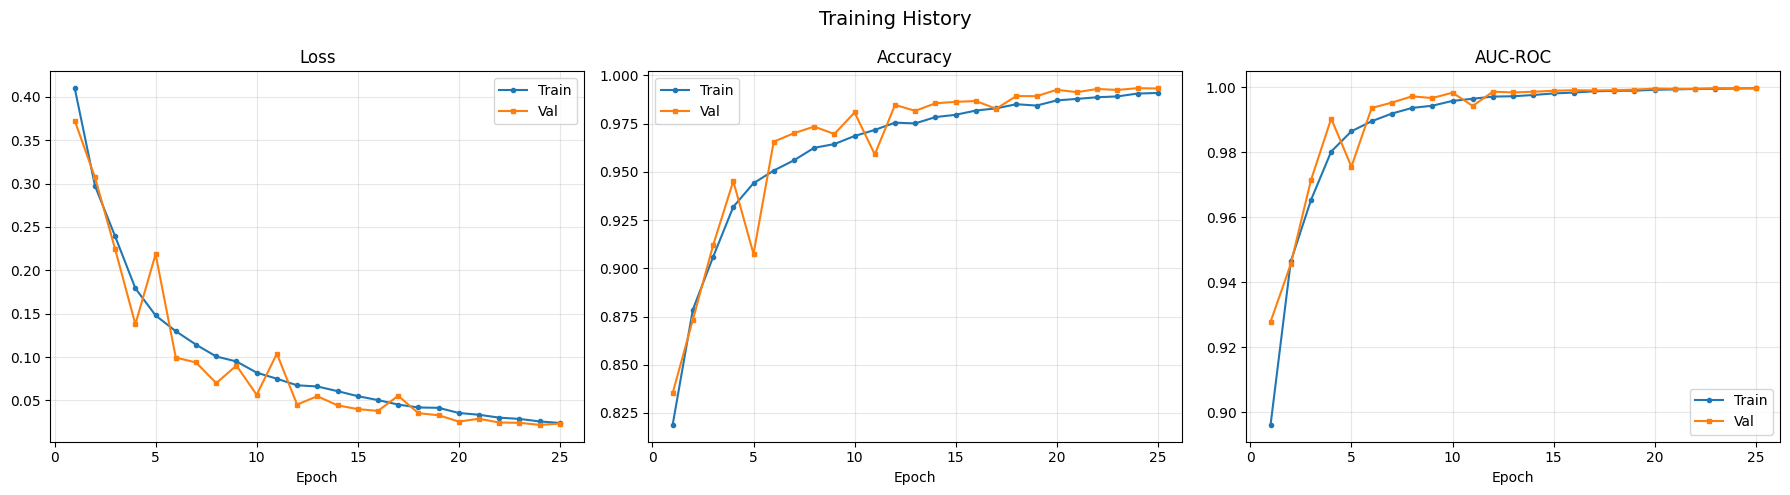

In [11]:
actual_epochs = len(history['tl'])
ep_range = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (tr_key, vl_key), title in zip(
    axes,
    [('tl','vl'), ('ta','va'), ('tu','vu')],
    ['Loss', 'Accuracy', 'AUC-ROC']
):
    ax.plot(ep_range, history[tr_key], 'o-', label='Train',markersize=3)
    ax.plot(ep_range, history[vl_key], 's-', label='Val',markersize=3)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

## Evaluation

Evaluating: 100%|██████████| 375/375 [01:14<00:00,  5.05it/s]


              precision    recall  f1-score   support

       Human       1.00      0.99      0.99      5997
          AI       0.99      1.00      0.99      5996

    accuracy                           0.99     11993
   macro avg       0.99      0.99      0.99     11993
weighted avg       0.99      0.99      0.99     11993



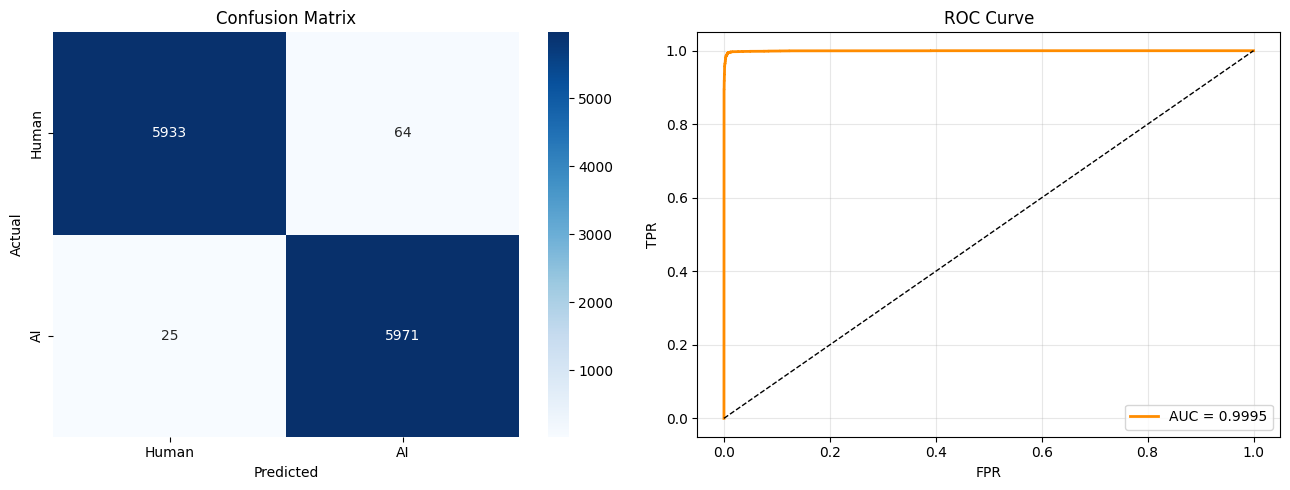

In [12]:
model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

all_probs, all_preds, all_true = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        probs = torch.sigmoid(model(imgs.to(device))).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_preds.extend((probs >= 0.5).astype(int).tolist())
        all_true.extend(labels.numpy().tolist())

print(classification_report(all_true, all_preds, target_names=['Human', 'AI']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human','AI'], yticklabels=['Human','AI'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(all_true, all_probs)
auc_val  = roc_auc_score(all_true, all_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/eval_plots.png', dpi=150)
plt.show()

## Predict

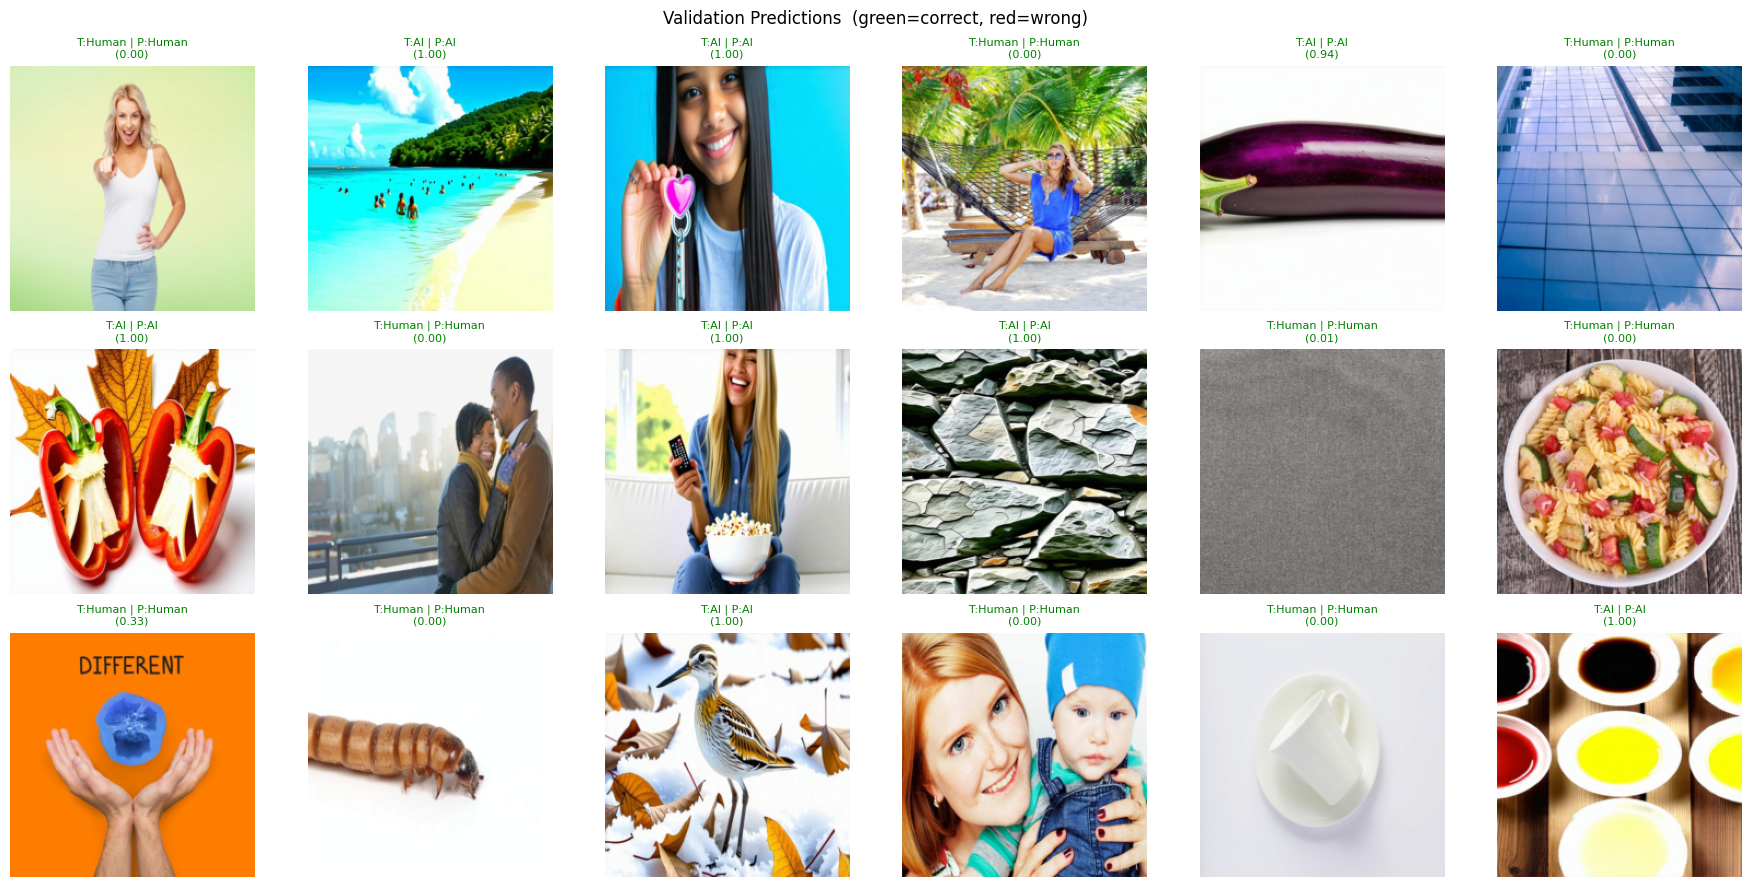

In [13]:
model.eval()
imgs_batch, lbls_batch = next(iter(val_loader))
with torch.no_grad():
    probs = torch.sigmoid(model(imgs_batch.to(device))).cpu().numpy()
preds = (probs >= 0.5).astype(int)

mean_np = np.array(mean)
std_np  = np.array(std)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i, ax in enumerate(axes.flatten()):
    if i >= len(imgs_batch):
        ax.axis('off')
        continue
    img = imgs_batch[i].permute(1, 2, 0).numpy()
    img = np.clip(img * std_np + mean_np, 0, 1)
    ax.imshow(img)
    true_lbl = 'AI' if lbls_batch[i].item() == 1 else 'Human'
    pred_lbl = 'AI' if preds[i] == 1 else 'Human'
    color    = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f'T:{true_lbl} | P:{pred_lbl}\n({probs[i]:.2f})', color=color, fontsize=8)
    ax.axis('off')

plt.suptitle('Validation Predictions  (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/predictions.png', dpi=150)
plt.show()

In [14]:
# Simpan full model (arsitektur + weights) untuk deployment ke website
torch.save({
    'model_state_dict' : model.state_dict(),
    'model_class' : 'ImprovedCNN',
    'img_size': img_size,
    'mean' : mean,
    'std' : std,
    'best_val_auc': early_stop.best_score,
    'classes' : {0: 'Human', 1: 'AI'}
}, '/kaggle/working/model_deployment.pth')

print(f'IMG_SIZE : {img_size}')
print(f'MEAN : {mean}')
print(f'STD : {std}')
print(f'Classes : 0=Human, 1=AI')

IMG_SIZE : 224
MEAN : [0.485, 0.456, 0.406]
STD : [0.229, 0.224, 0.225]
Classes : 0=Human, 1=AI
